# Assignment 3: Regularization & Optimization

**Name:** Hridayanshu Raj Acharya  
**ID:** 032280-22  
**Date:** 2026-04-19  
**Dataset:** Fashion MNIST (Zalando, via torchvision) 

## Objective

- Implement and compare L1, L2, and Dropout regularization on a neural network trained on Fashion MNIST
- Demonstrate overfitting on an unregularized baseline model
- Compare SGD and Adam optimizers in terms of convergence speed and generalization
- Experiment with Batch Normalization and analyze its effect on training stability
- Visualize train vs. validation loss/accuracy curves and analyze bias-variance trade-offs

## Theoretical Background

### Overfitting
Overfitting occurs when a model memorizes training data but fails to generalize to unseen data, visible as a growing gap between training and validation loss.

### L2 Regularization (Weight Decay)
Adds a penalty proportional to the square of weights to the loss:
$$L_{total} = L_{data} + \lambda \sum w_i^2$$
Encourages small weights and reduces model complexity.

### L1 Regularization
Adds a penalty proportional to the absolute value of weights:
$$L_{total} = L_{data} + \lambda \sum |w_i|$$
Encourages sparsity, many weights are pushed exactly to zero.

### Dropout
Randomly zeros out a fraction $p$ of neurons during each forward pass in training,
preventing co-adaptation and acting as an ensemble of subnetworks.

### Batch Normalization
Normalizes layer inputs across the mini-batch:
$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$
Stabilizes training, allows higher learning rates, and has a mild regularizing effect.

### SGD vs Adam
- **SGD**: Updates weights using the raw gradient. Simple but slow and sensitive to learning rate.
- **Adam**: Adaptive optimizer combining momentum and RMSProp. Faster convergence and more robust to hyperparameter choices.

## Dataset Description

- **Source**: Zalando's Fashion MNIST, loaded via `torchvision.datasets.FashionMNIST`
- **Total Samples**: 70,000 grayscale images (60,000 train / 10,000 test)
- **Image Size**: 28×28 pixels, single channel
- **Classes**: 10 clothing categories: T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot
- **Split Strategy**: 60,000 training images split into 50,000 train / 10,000 validation; 10,000 held-out test set

## Implementation

In [1]:
#Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split # for batching and splitting datasets
from torchvision import datasets, transforms  # built-in datasets and preprocessing tools
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Setting random seeds for reproducibility
# This ensures we get the same results every time we run the code
torch.manual_seed(42)
np.random.seed(42)

# Selecting device (GPU if available, otherwise CPU)
# This helps speed up training when CUDA (GPU) is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


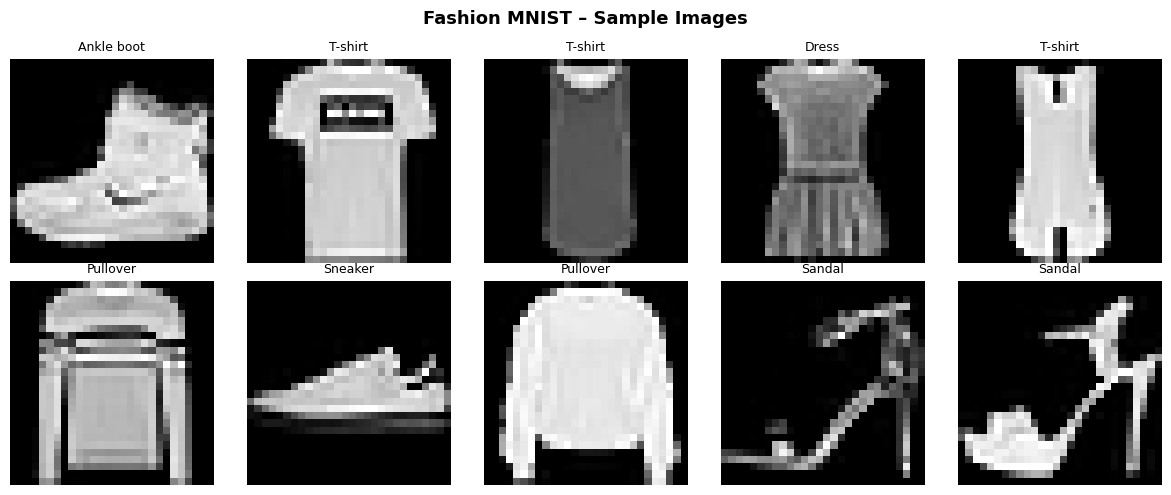

Train: 50000 | Val: 10000 | Test: 10000


In [2]:
# Define preprocessing steps for the images
transform = transforms.Compose([
    transforms.ToTensor(),  # converts image (0–255) to tensor (0–1)
    transforms.Normalize((0.2860,), (0.3530,)) # normalize using dataset mean & std (helps training)
])

# Load the FashionMNIST dataset
full_train = datasets.FashionMNIST(
    root='./data',      # where the dataset will be stored
    train=True,         # load training data
    download=True,      # download if not already present
    transform=transform # apply preprocessing
)

test_set = datasets.FashionMNIST(
    root='./data',
    train=False,        # load test data
    download=True,
    transform=transform
)

# Split training data into training and validation sets
train_set, val_set = random_split(full_train, [50000, 10000])

# Create DataLoaders for batching
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)   # shuffle for better training
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)  # no shuffle needed
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False)

# Class labels for FashionMNIST (for visualization)
CLASS_NAMES = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Display some sample images from the dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))  # create a 2x5 grid

for i, ax in enumerate(axes.flat):
    img, label = full_train[i]                   # get image and its label
    ax.imshow(img.squeeze(), cmap='gray')        # remove channel dim and show image
    ax.set_title(CLASS_NAMES[label], fontsize=9) # show class name as title
    ax.axis('off')                               # hide axis

# Add overall title
plt.suptitle('Fashion MNIST – Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print dataset sizes
print(f'Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}')

### Model Definitions

Three architectures are defined: all share the same layer sizes (784 → 512 → 256 → 128 → 10)
but differ in their regularization components:

| Model | Regularization |
|---|---|
| BaselineModel | None |
| DropoutModel | Dropout after each hidden layer |
| BatchNormModel | Batch Normalization after each linear layer |

L1 and L2 regularization are applied to the **BaselineModel** via the optimizer or loss function.

In [3]:
# Baseline model (no regularization)
class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()  # initialize parent class (nn.Module)

        # Define a simple fully connected neural network
        self.net = nn.Sequential(
            nn.Flatten(), # convert 28x28 image into 1D vector (784)

            nn.Linear(784, 512), # first dense layer
            nn.ReLU(),  # activation function

            nn.Linear(512, 256),# second layer
            nn.ReLU(),

            nn.Linear(256, 128), # third layer
            nn.ReLU(),

            nn.Linear(128, 10) # output layer (10 classes)
        )

    # Forward pass
    def forward(self, x):
        return self.net(x)


# Model with Dropout regularization
class DropoutModel(nn.Module):
    def __init__(self, p=0.4):  # p = probability of dropping neurons
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(p),  # randomly drop neurons during training

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


# Model with Batch Normalization
class BatchNormModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784, 512),
            nn.BatchNorm1d(512), # normalize activations
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


# Confirmation print
print('Models defined: BaselineModel, DropoutModel, BatchNormModel')

Models defined: BaselineModel, DropoutModel, BatchNormModel


### Training Utilities

- `train_epoch()` : runs one epoch, supports optional L1 penalty
- `evaluate()` : computes loss and accuracy on any loader without gradient updates
- `train_model()` : full training loop, logs history for plotting

In [4]:
# Train the model for one epoch
def train_epoch(model, loader, optimizer, criterion, l1_lambda=0.0):
    model.train()  # set model to training mode (enables dropout, batchnorm updates)

    total_loss, correct = 0.0, 0  # track total loss and correct predictions

    for X, y in loader:  # loop over batches
        X, y = X.to(device), y.to(device)  # move data to GPU/CPU

        optimizer.zero_grad()  # clear previous gradients

        out  = model(X)        # forward pass
        loss = criterion(out, y)  # compute loss (CrossEntropy)

        # Add L1 regularization if specified
        if l1_lambda > 0:
            l1_penalty = sum(p.abs().sum() for p in model.parameters())  # sum of absolute weights
            loss = loss + l1_lambda * l1_penalty  # add L1 term to loss

        loss.backward()  # backpropagation (compute gradients)
        optimizer.step() # update model weights

        # accumulate loss and accuracy
        total_loss += loss.item() * X.size(0)  # multiply by batch size
        correct    += (out.argmax(1) == y).sum().item()  # count correct predictions

    n = len(loader.dataset)  # total number of samples
    return total_loss / n, correct / n  # return average loss and accuracy


# Evaluate model (validation/test)
def evaluate(model, loader, criterion):
    model.eval()  # set model to evaluation mode (disables dropout, batchnorm updates)

    total_loss, correct = 0.0, 0

    # no gradient computation (saves memory and speeds up)
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            out  = model(X)          # forward pass
            loss = criterion(out, y)

            total_loss += loss.item() * X.size(0)
            correct    += (out.argmax(1) == y).sum().item()

    n = len(loader.dataset)
    return total_loss / n, correct / n


# Full training loop across multiple epochs
def train_model(model, optimizer, epochs=25, l1_lambda=0.0, label=''):
    criterion = nn.CrossEntropyLoss()  # classification loss function

    # dictionary to store metrics for plotting later
    history = {
        'train_loss': [], 
        'val_loss': [], 
        'train_acc': [], 
        'val_acc': []
    }

    print(f'\nTraining: {label}')

    for epoch in range(1, epochs + 1):
        # train for one epoch
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, l1_lambda)

        # evaluate on validation set
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        # store results
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        # print progress every 5 epochs
        if epoch % 5 == 0:
            print(f'  Epoch {epoch:02d} | Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} '
                  f'| Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}')

    return history  # return all recorded metrics

## Experiments

| # | Experiment | Model | Optimizer | Regularization |
|---|---|---|---|---|
| 1 | Overfitting Baseline | BaselineModel | Adam | None |
| 2 | L2 Regularization | BaselineModel | Adam + weight_decay=1e-4 | L2 |
| 3 | L1 Regularization | BaselineModel | Adam | L1 λ=1e-5 |
| 4 | Dropout | DropoutModel (p=0.4) | Adam | Dropout |
| 5 | Batch Normalization | BatchNormModel | Adam | BatchNorm |
| 6 | SGD vs Adam | DropoutModel (p=0.3) | SGD / Adam | L2 + Dropout |

In [5]:
# Experiment 1: Baseline (no regularization)
baseline_model = BaselineModel().to(device)  # initialize model and move to device (CPU/GPU)

hist_baseline = train_model(
    baseline_model,
    optim.Adam(baseline_model.parameters(), lr=1e-3),  # Adam optimizer
    epochs=30,
    label='Experiment 1 – Baseline (No Regularization)'
)


# Experiment 2: L2 Regularization (weight decay)
l2_model = BaselineModel().to(device)

hist_l2 = train_model(
    l2_model,
    optim.Adam(l2_model.parameters(), lr=1e-3, weight_decay=1e-4),  # L2 applied via weight_decay
    epochs=30,
    label='Experiment 2 – L2 Regularization'
)


# Experiment 3: L1 Regularization (manual)
l1_model = BaselineModel().to(device)

hist_l1 = train_model(
    l1_model,
    optim.Adam(l1_model.parameters(), lr=1e-3),
    epochs=30,
    l1_lambda=1e-5,  # controls strength of L1 penalty
    label='Experiment 3 – L1 Regularization'
)


# Experiment 4: Dropout Regularization
dropout_model = DropoutModel(p=0.4).to(device)  # dropout probability = 40%

hist_dropout = train_model(
    dropout_model,
    optim.Adam(dropout_model.parameters(), lr=1e-3),
    epochs=30,
    label='Experiment 4 – Dropout (p=0.4)'
)


# Experiment 5: Batch Normalization
bn_model = BatchNormModel().to(device)

hist_bn = train_model(
    bn_model,
    optim.Adam(bn_model.parameters(), lr=1e-3),
    epochs=30,
    label='Experiment 5 – Batch Normalization'
)


# Experiment 6a: SGD optimizer (with momentum + L2)
sgd_model = DropoutModel(p=0.3).to(device)

hist_sgd = train_model(
    sgd_model,
    optim.SGD(
        sgd_model.parameters(),
        lr=0.01,           # higher learning rate than Adam
        momentum=0.9,      # helps accelerate convergence
        weight_decay=1e-4  # L2 regularization
    ),
    epochs=30,
    label='Experiment 6a: SGD + Momentum'
)


# Experiment 6b: Adam optimizer (with L2)
adam_model = DropoutModel(p=0.3).to(device)

hist_adam = train_model(
    adam_model,
    optim.Adam(
        adam_model.parameters(),
        lr=1e-3,
        weight_decay=1e-4  # L2 regularization
    ),
    epochs=30,
    label='Experiment 6b – Adam'
)


Training: Experiment 1 – Baseline (No Regularization)
  Epoch 05 | Train Loss: 0.2689  Acc: 0.8993 | Val Loss: 0.3262  Acc: 0.8834
  Epoch 10 | Train Loss: 0.1980  Acc: 0.9256 | Val Loss: 0.3063  Acc: 0.8954
  Epoch 15 | Train Loss: 0.1512  Acc: 0.9428 | Val Loss: 0.3466  Acc: 0.8921
  Epoch 20 | Train Loss: 0.1234  Acc: 0.9530 | Val Loss: 0.3827  Acc: 0.8904
  Epoch 25 | Train Loss: 0.0929  Acc: 0.9639 | Val Loss: 0.4599  Acc: 0.8951
  Epoch 30 | Train Loss: 0.0809  Acc: 0.9699 | Val Loss: 0.4676  Acc: 0.8943

Training: Experiment 2 – L2 Regularization
  Epoch 05 | Train Loss: 0.2788  Acc: 0.8957 | Val Loss: 0.3170  Acc: 0.8822
  Epoch 10 | Train Loss: 0.2168  Acc: 0.9189 | Val Loss: 0.3379  Acc: 0.8846
  Epoch 15 | Train Loss: 0.1791  Acc: 0.9322 | Val Loss: 0.3480  Acc: 0.8858
  Epoch 20 | Train Loss: 0.1467  Acc: 0.9439 | Val Loss: 0.3492  Acc: 0.8898
  Epoch 25 | Train Loss: 0.1266  Acc: 0.9516 | Val Loss: 0.3582  Acc: 0.8956
  Epoch 30 | Train Loss: 0.1070  Acc: 0.9591 | Val Los

## Results

### Plot Helper
The `plot_loss()` function below plots train (dashed) vs validation (solid) loss and accuracy
for any set of experiments on the same axes for easy comparison.

In [6]:
# Function to plot training vs validation loss and accuracy
def plot_loss(histories, labels, title):
    
    # Create a figure with 2 subplots (one for loss, one for accuracy)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = plt.cm.tab10.colors  # predefined color set for multiple lines

    # Loop through each experiment's history and label
    for i, (hist, label) in enumerate(zip(histories, labels)):
        ep = range(1, len(hist['train_loss']) + 1)  # epoch numbers

        # Plot training loss (dashed line)
        axes[0].plot(ep, hist['train_loss'], '--', color=colors[i], alpha=0.6)
        
        # Plot validation loss (solid line)
        axes[0].plot(ep, hist['val_loss'], '-', color=colors[i], label=label)

        # Plot training accuracy (dashed line)
        axes[1].plot(ep, hist['train_acc'], '--', color=colors[i], alpha=0.6)
        
        # Plot validation accuracy (solid line)
        axes[1].plot(ep, hist['val_acc'], '-', color=colors[i], label=label)

    # Set titles, labels, legends, and grid for both plots
    for ax, ylabel, ttl in zip(
        axes,
        ['Loss', 'Accuracy'],
        ['Train (dashed) vs Validation Loss',
         'Train (dashed) vs Validation Accuracy']
    ):
        ax.set_title(ttl)          # subplot title
        ax.set_xlabel('Epoch')     # x-axis label
        ax.set_ylabel(ylabel)      # y-axis label
        ax.legend(fontsize=8)      # legend showing experiment names
        ax.grid(alpha=0.3)         # light grid for readability

    # Main title for the entire figure
    plt.suptitle(title, fontsize=13, fontweight='bold')
    
    plt.tight_layout()  # adjust spacing
    plt.show()          # display the plots

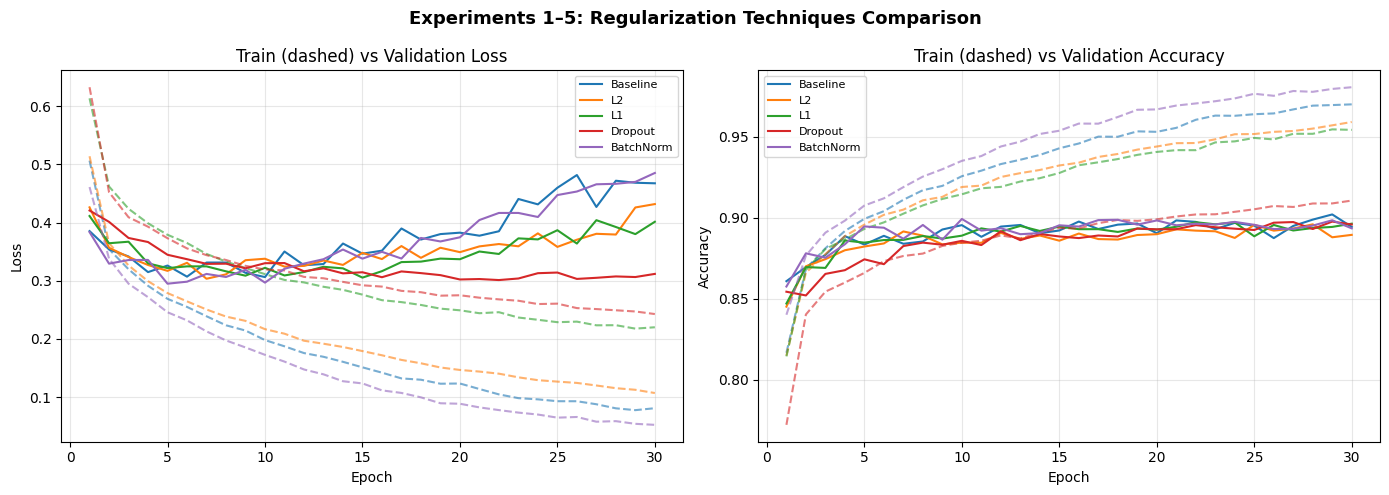

In [7]:
# Plot comparison of different regularization techniques (Experiments 1–5)
plot_loss(
    [hist_baseline, hist_l2, hist_l1, hist_dropout, hist_bn],  # histories from each experiment
    ['Baseline', 'L2', 'L1', 'Dropout', 'BatchNorm'],          # labels for legend
    'Experiments 1–5: Regularization Techniques Comparison'    # overall title
)

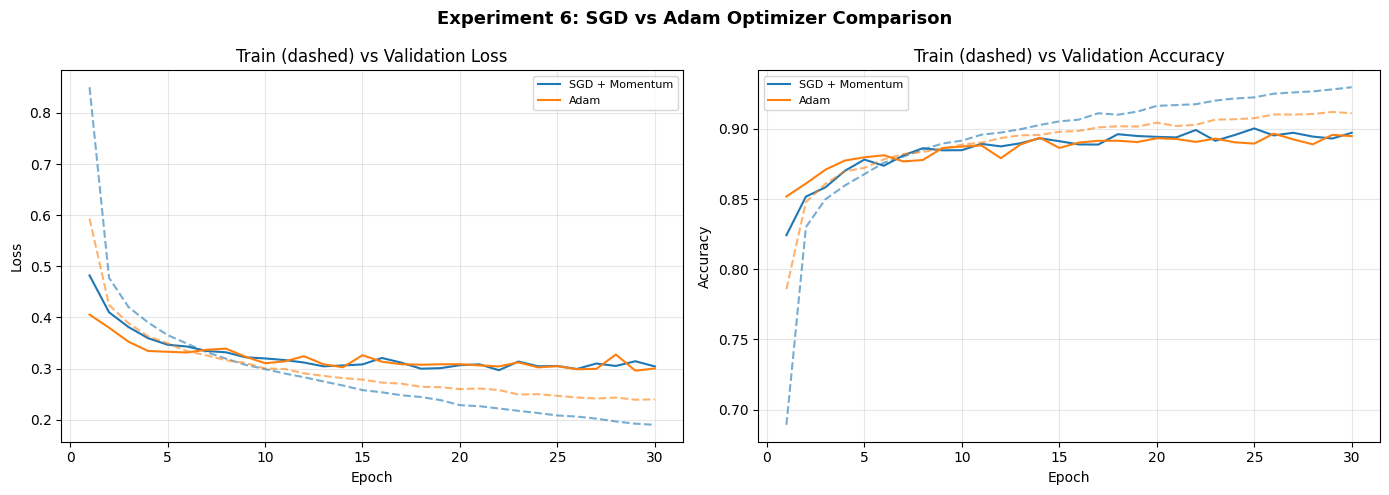

In [8]:
# Plot comparison between SGD and Adam optimizers (Experiment 6)
plot_loss(
    [hist_sgd, hist_adam],  # training histories from both optimizers
    ['SGD + Momentum', 'Adam'],  # labels for legend
    'Experiment 6: SGD vs Adam Optimizer Comparison'  # plot title
)

    Model  Train Loss  Val Loss  Val Acc (%)  Overfit Gap
 Baseline      0.0809    0.4676        89.43       0.3867
   L2 Reg      0.1070    0.4318        88.94       0.3249
   L1 Reg      0.2201    0.4015        89.63       0.1814
  Dropout      0.2428    0.3118        89.58       0.0690
BatchNorm      0.0523    0.4853        89.34       0.4330
      SGD      0.1901    0.3043        89.73       0.1142
     Adam      0.2400    0.3003        89.49       0.0603


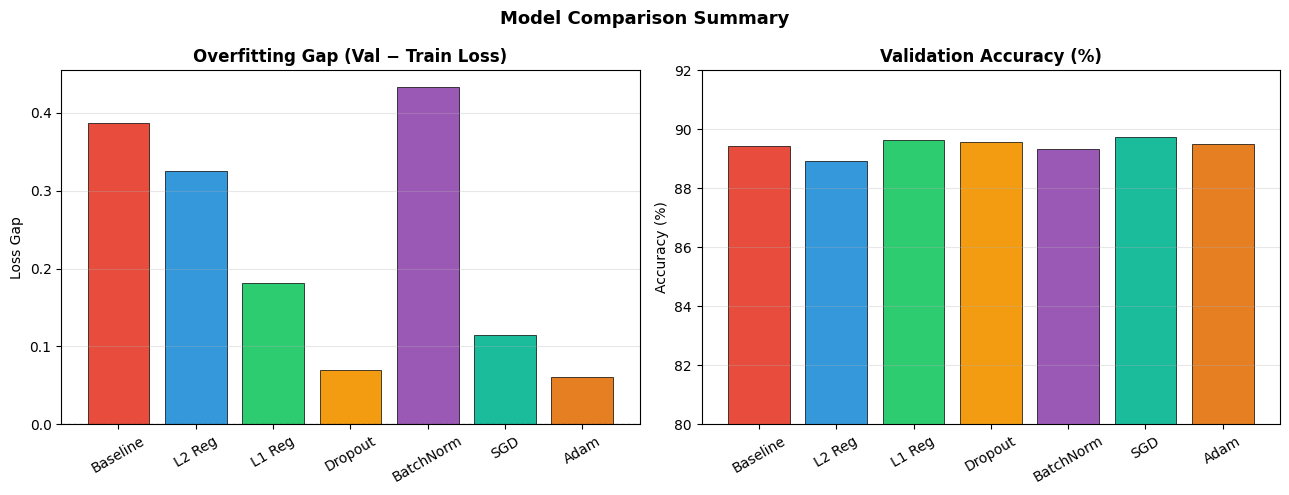

In [9]:
# Combine all experiment histories into one list
all_hists  = [hist_baseline, hist_l2, hist_l1, hist_dropout, hist_bn, hist_sgd, hist_adam]

# Corresponding model names for display
all_labels = ['Baseline', 'L2 Reg', 'L1 Reg', 'Dropout', 'BatchNorm', 'SGD', 'Adam']

# Create a summary dictionary to compare final performance of all models
summary = {
    'Model': all_labels,

    # Final training loss (last epoch)
    'Train Loss': [round(h['train_loss'][-1], 4) for h in all_hists],

    # Final validation loss (last epoch)
    'Val Loss': [round(h['val_loss'][-1], 4) for h in all_hists],

    # Final validation accuracy (converted to percentage)
    'Val Acc (%)': [round(h['val_acc'][-1] * 100, 2) for h in all_hists],

    # Overfitting indicator: difference between validation and training loss
    'Overfit Gap': [round(h['val_loss'][-1] - h['train_loss'][-1], 4) for h in all_hists],
}

# Convert summary dictionary into a DataFrame for clean tabular display
df = pd.DataFrame(summary)

# Print table without index for cleaner output
print(df.to_string(index=False))


# Colors for bar plots (one per model)
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Overfitting Gap
axes[0].bar(df['Model'], df['Overfit Gap'], color=colors, edgecolor='black', linewidth=0.5)

# Reference line at 0 (no overfitting)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

axes[0].set_title('Overfitting Gap (Val − Train Loss)', fontweight='bold')
axes[0].set_ylabel('Loss Gap')
axes[0].tick_params(axis='x', rotation=30)  # rotate labels for readability
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Validation Accuracy
axes[1].bar(df['Model'], df['Val Acc (%)'], color=colors, edgecolor='black', linewidth=0.5)

axes[1].set_title('Validation Accuracy (%)', fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')

# Fix y-axis range for better visual comparison
axes[1].set_ylim([80, 92])

axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)


# Overall title for the figure
plt.suptitle('Model Comparison Summary', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
#final test accuracy

criterion = nn.CrossEntropyLoss()
models_dict = {
    'Baseline':  baseline_model,
    'L2 Reg':    l2_model,
    'L1 Reg':    l1_model,
    'Dropout':   dropout_model,
    'BatchNorm': bn_model,
    'SGD':       sgd_model,
    'Adam':      adam_model
}
print('=== Final Test Set Accuracy ===')
for name, model in models_dict.items():
    _, acc = evaluate(model, test_loader, criterion)
    print(f'  {name:12s}: {acc * 100:.2f}%')

=== Final Test Set Accuracy ===
  Baseline    : 88.75%
  L2 Reg      : 88.68%
  L1 Reg      : 88.74%
  Dropout     : 88.65%
  BatchNorm   : 88.60%
  SGD         : 88.85%
  Adam        : 88.79%


## Analysis & Discussion

### Overfitting (Experiment 1: Baseline)
The baseline model is the clearest example of overfitting in this experiment.
Train loss dropped to **0.0809** while val loss rose to **0.4676**, giving an overfit gap of **0.3867**
, the second largest gap observed. Train accuracy reached 96.99% but val accuracy was only 89.43%,
confirming the model memorized training data rather than learning generalizable features.

### Batch Normalization (Experiment 5)
Surprisingly, BatchNorm produced the **worst overfitting** of all experiments, the largest overfit
gap of **0.4330** (train loss: 0.0523, val loss: 0.4853). Train accuracy hit 98.05% while val
accuracy was only 89.34%. BatchNorm accelerated convergence aggressively, causing the model to
overfit faster and more severely. This confirms that BatchNorm is not a substitute for
regularization, it stabilizes training but does not prevent overfitting on its own.

### L2 Regularization (Experiment 2)
L2 reduced the overfit gap to **0.3249** compared to the baseline's 0.3867, a modest improvement.
Val accuracy (88.94%) was actually slightly lower than baseline, suggesting the weight_decay value
(1e-4) may have been too strong, slightly constraining the model's capacity. L2 is effective but
sensitive to the choice of λ.

### L1 Regularization (Experiment 3)
L1 performed better than expected, reducing the overfit gap to **0.1814**. The sparsity-inducing
penalty slowed down train loss reduction (train loss: 0.2201 at epoch 30) while keeping val loss
relatively controlled at 0.4015. Val accuracy (89.63%) was among the highest, suggesting that
feature sparsity was beneficial here. L1 outperformed L2 in generalization on these results.

### Dropout (Experiment 4)
Dropout (p=0.4) achieved the **second smallest overfit gap of 0.0690**, a dramatic improvement
over the baseline. Train and val loss stayed close throughout training (0.2428 vs 0.3118 at epoch
30). Val accuracy reached 89.58%. The trade-off is slower convergence, train accuracy only
reached 91.06% by epoch 30 compared to 96.99% for the baseline, but the model generalizes far
better.

### SGD vs Adam (Experiment 6)
This is the most interesting finding. Both used the same DropoutModel (p=0.3) with L2 weight decay:

- **Adam** achieved the **smallest overfit gap of 0.0603** (train: 0.2400, val: 0.3003), the best
  generalization across all experiments.
- **SGD + Momentum** had a gap of **0.1142**, val loss of 0.3043, and notably achieved the
  **highest val accuracy of 89.73%**.
- Contrary to the common assumption that Adam is always faster, SGD's val loss (0.3043) was nearly
  identical to Adam's (0.3003) at epoch 30, and SGD's val accuracy was slightly higher.
- Both optimizers with Dropout + L2 generalized better than all regularization-only experiments,
  confirming that combining techniques is most effective.

### Bias-Variance Summary

| Model | Train Loss | Val Loss | Overfit Gap | Observation |
|---|---|---|---|---|
| Baseline | 0.0809 | 0.4676 | 0.3867 | Clear overfitting |
| L2 Reg | 0.1070 | 0.4318 | 0.3249 | Modest improvement |
| L1 Reg | 0.2201 | 0.4015 | 0.1814 | Better than L2 here |
| Dropout | 0.2428 | 0.3118 | 0.0690 | Strong regularization |
| BatchNorm | 0.0523 | 0.4853 | 0.4330 | Worst overfit: no regularization effect |
| SGD | 0.1901 | 0.3043 | 0.1142 | Good generalization, highest val acc |
| Adam | 0.2400 | 0.3003 | 0.0603 | Best generalization gap overall |

## Conclusion

- **Baseline overfitting was clearly demonstrated**, a train-val loss gap of 0.3867 confirms that
  an unregularized deep network memorizes training data on Fashion MNIST rather than generalizing.
- **Batch Normalization alone caused the worst overfitting** (gap: 0.4330), showing that it
  accelerates training but does not regularize, it must be combined with Dropout or weight decay
  in practice.
- **Dropout (p=0.4) was the most effective standalone regularizer**, reducing the overfit gap to
  0.0690 by forcing the network to learn redundant, robust representations across subnetworks.
- **L1 outperformed L2 regularization** in this experiment (gap: 0.1814 vs 0.3249), suggesting
  that the sparsity-inducing property of L1 was beneficial for this architecture and dataset,
  though L2 is generally more stable across settings.
- **Adam achieved the best generalization gap (0.0603)** while **SGD achieved the highest val
  accuracy (89.73%)**, both used Dropout + L2, confirming that combining regularization with
  a well-tuned optimizer is the most effective strategy.
- **Key takeaway**: No single technique dominates in all metrics. Dropout combined with an adaptive
  optimizer (Adam) minimizes overfitting, while SGD with momentum may yield marginally higher
  accuracy with sufficient training. Practitioners should combine Dropout, weight decay, and
  BatchNorm together rather than relying on any one method alone.